In [ ]:
Sa se foloseasca un algoritm de clasificare a imaginilor (etapa de inferenta/testare) si sa se stabileasca performanta acestui algoritm de clasificare binara (imagini cu biciclete vs. imagini fara biciclete).

In [2]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key ="CCUp8BHiZaUU4sX0T28lXKFydNIdAiWKNP2QMi9PAQ3dJZaL2rc0JQQJ99BCAC5RqLJXJ3w3AAAFACOGHHIb"
endpoint = "https://numenou.cognitiveservices.azure.com/"
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

def readImgs():
    crtDir =  os.getcwd()
    filePath = os.path.join(crtDir,'Bikes')
    images=[]
    for filename in os.listdir(filePath):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            path=os.path.join(filePath,filename)
            images.append(path)
    return images

def evalClassificationV1(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
    
    cm = confusion_matrix(realLabels, computedLabels, labels = labelNames)
    acc = accuracy_score(realLabels, computedLabels)
    precision = precision_score(realLabels, computedLabels, average = None, labels = labelNames)
    recall = recall_score(realLabels, computedLabels, average = None, labels = labelNames)
    return acc, precision, recall 

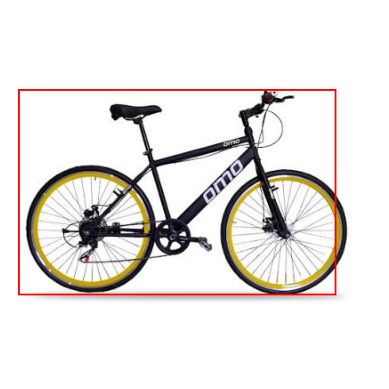

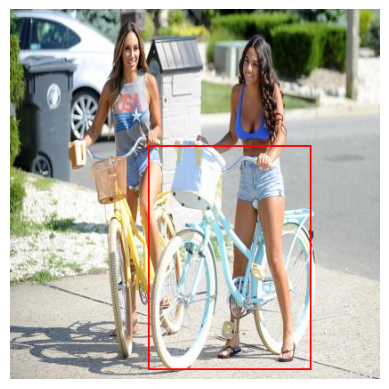

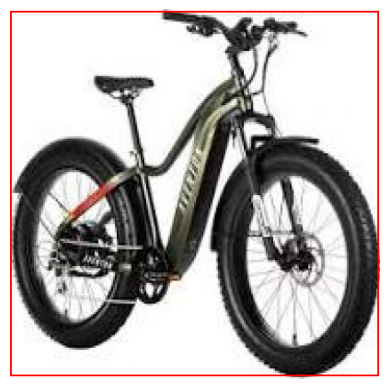

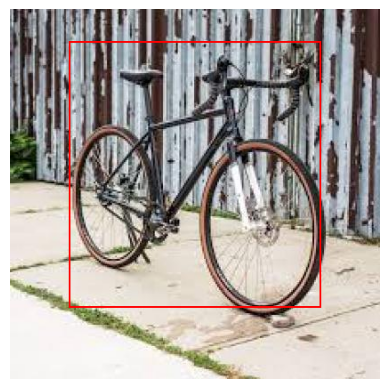

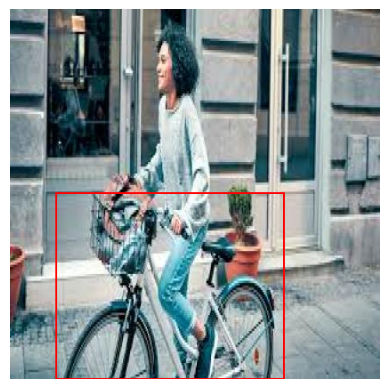

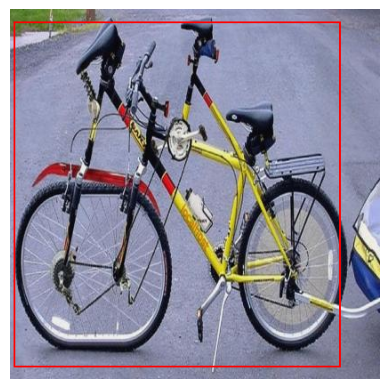

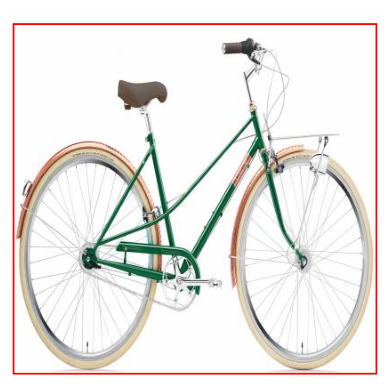

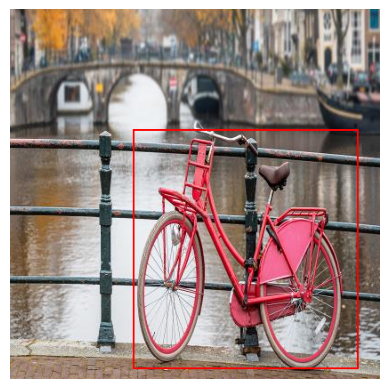

Total imagini cu biciclete identificate:  8
Total imagini cu biciclete:  10
Eroare:  1.0 

Total imagini fara biciclete identificate:  12
Total imagini cu biciclete:  10
Eroare:  1.0 

Ground truth:  ['bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike']
Computed values:  ['bike', 'bike', 'bike', 'bike', 'no-bike', 'bike', 'no-bike', 'bike', 'bike', 'bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike', 'no-bike']
acc:  0.9
precision:  [1.         0.83333333]
recall:  [0.8 1. ]


['bike',
 'bike',
 'bike',
 'bike',
 'no-bike',
 'bike',
 'no-bike',
 'bike',
 'bike',
 'bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike',
 'no-bike']

In [3]:
from PIL import Image,ImageDraw
import matplotlib.pyplot as plt
import time
from math import sqrt
def bikesInImg():
    groundTruth=["bike","bike","bike","bike","bike","bike","bike","bike","bike","bike","no-bike","no-bike","no-bike","no-bike","no-bike","no-bike","no-bike","no-bike","no-bike","no-bike"]
    computedValues=[]
    imagini=readImgs()
    nrCuB=0
    nrFaB=0
    for imPath in imagini:
        img=Image.open(imPath)
        draw = ImageDraw.Draw(img)
        time.sleep(5)
        with open(imPath,"rb") as ims:
            res=computervision_client.analyze_image_in_stream(ims,visual_features=[VisualFeatureTypes.objects])
        found=False
        for ob in res.objects:
            if ob.object_property.lower() == "bicycle":
                x,y,w,h=ob.rectangle.x, ob.rectangle.y,ob.rectangle.w,ob.rectangle.h
                draw.rectangle([x,y,x+w,y+h], outline="red", width=2)
                plt.imshow(img)
                plt.axis("off")  
                plt.show()
                found=True
                break
        if found:
            nrCuB+=1
            computedValues.append("bike")
        else:
            nrFaB+=1
            computedValues.append("no-bike")
    print("Total imagini cu biciclete identificate: ",nrCuB)
    print("Total imagini cu biciclete: ",10)
    err=(sqrt((nrCuB-10)**2))/2
    print("Eroare: ",err,"\n")
    print("Total imagini fara biciclete identificate: ",nrFaB)
    print("Total imagini cu biciclete: ",10)
    err=(sqrt((nrFaB-10)**2))/2
    print("Eroare: ",err,"\n")
    acc,prec,recal=evalClassificationV1(groundTruth,computedValues,['bike','no-bike'])
    print("Ground truth: ",groundTruth)
    print("Computed values: ",computedValues)
    #overall performance(predictii corecte/numarul total de samples)
    print("acc: ",acc)
    #precizia predictiilor pozitive TP/(TP+FP)
    print("precision: ",prec)
    #cat de mult din TP sunt acoperite de predictie TP/(TP+FN)
    print("recall: ",recal)

    return computedValues

bikesInImg()
            
                

In [ ]:
b. sa se eticheteze (fara ajutorul algoritmilor de AI) aceste imagini cu chenare care sa incadreze cat mai exact bicicletele. Care task dureaza mai mult (cel de la punctul a sau cel de la punctul b)?

c. sa se determine performanta algoritmului de la punctul a avand in vedere etichetarile realizate la punctul b (se vor folosi cel putin 2 metrici).

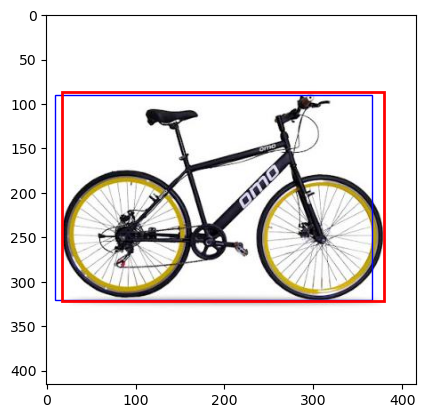

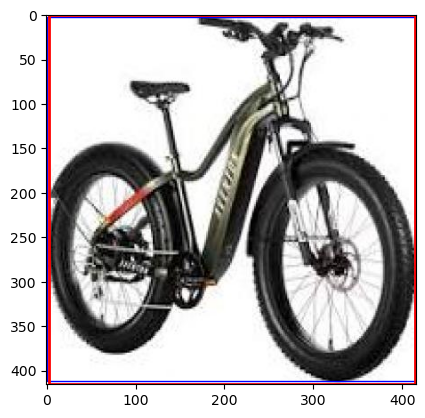

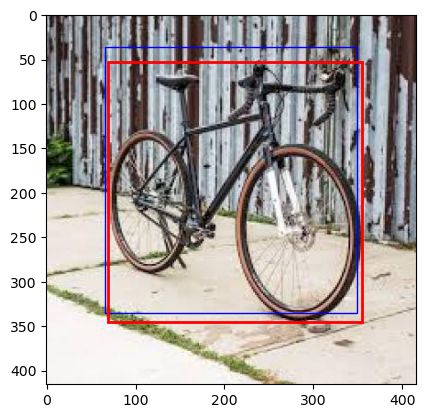

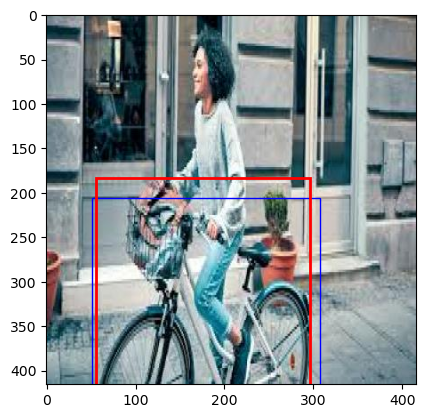

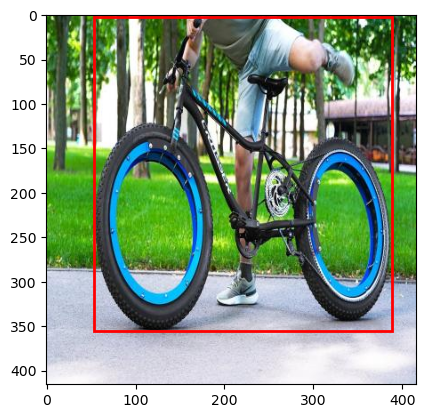

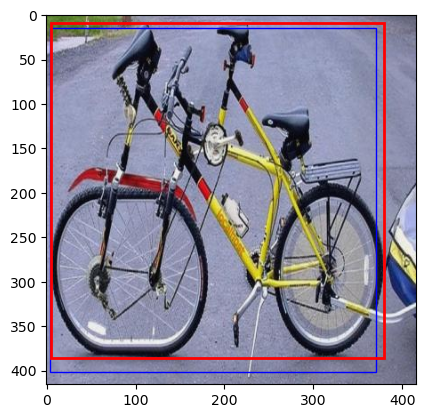

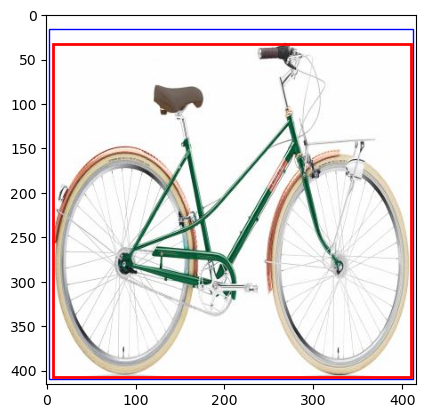

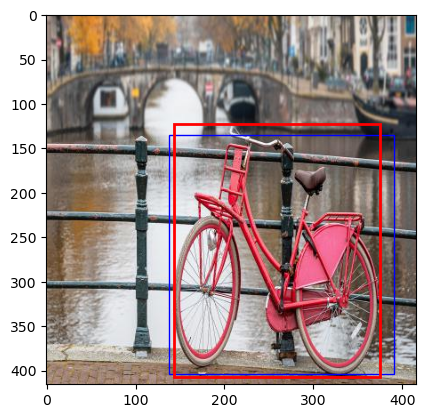

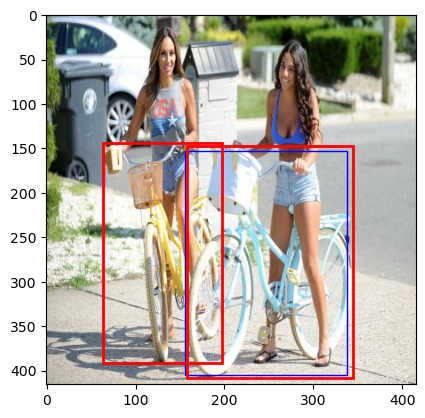

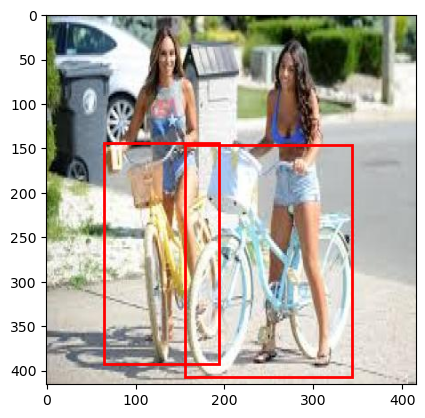

Imagine:  Bikes/bike02.jpg IOU:  0.9186019774660842
Imagine:  Bikes/bike04.jpg IOU:  0.9737923647413582
Imagine:  Bikes/bike05.jpg IOU:  0.8850626427632035
Imagine:  Bikes/bike07.jpg IOU:  0.079317697228145
Imagine:  Bikes/bike08.jpg IOU:  0
Imagine:  Bikes/bike09.jpg IOU:  0.9351675254063594
Imagine:  Bikes/bike1.jpg IOU:  0.8850574712643678
Imagine:  Bikes/bike10.jpg IOU:  0.6695110312692977
Imagine:  Bikes/bike03.jpg IOU:  0.6869275603663614
Imagine:  Bikes/bike06.jpg IOU:  0
Imagine:  Bikes/bike06.jpg IOU:  0
 acc:  0.4666666666666667 prec:  0.5833333333333334  recall:  0.7


In [4]:
import pandas as pd
from collections import defaultdict
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1_gt, y1_gt, x2_gt, y2_gt = box2

    xmax = max(x1, x1_gt)
    ymax = max(y1, y1_gt)
    xmin = min(x2, x2_gt)
    ymin = min(y2, y2_gt)

    if xmin < xmax or ymin < ymax:
        return 0.0

    intersection_area = (xmin - xmax) * (ymin - ymax)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2_gt - x1_gt) * (y2_gt - y1_gt)
    
    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

def evaluate_model(detected_boxes, ground_truth_boxes):
    tp = 0  
    fp = 0  
    fn = 0 
    for image,boxes in ground_truth_boxes.items():
        matched=False
        for i in range(len( boxes)):
            if(len(detected_boxes[image])>i):
                iou = calculate_iou(detected_boxes[image][i], ground_truth_boxes[image][i])
            else:
                iou=0
            print("Imagine: ",image,"IOU: ",iou)
            if iou >= 0.5:
                tp += 1
                matched = True
                break
        if not matched:
            fn += 1  
            

   
    fp = 12 - tp 
   
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    accuracy = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else 0 

    return precision, recall, accuracy


def displayBoundingBoxes(file):
    df=pd.read_csv(file)
    grouped=df.groupby('image')
    groundTr=defaultdict(list)
    computed=defaultdict(list)

    for index,row in df.iterrows():
        xmin=int(row["xmin"])
        xmax=int(row["xmax"])
        ymin=int(row["ymin"])
        ymax=int(row["ymax"])
        nume=row["image"]
        gt=[xmin,ymin,xmax,ymax]
        groundTr[nume].append(gt)

    for image,poz in groundTr.items():
        fig, ax=plt.subplots()

        img=open(image,"rb")
        res=computervision_client.analyze_image_in_stream(img,visual_features=[VisualFeatureTypes.objects])
        found=False

        for ob in res.objects:
            if ob.object_property=="bicycle":
                x,y,w,h=ob.rectangle.x, ob.rectangle.y,ob.rectangle.w,ob.rectangle.h
                rect=patches.Rectangle((x,y),w,h,linewidth=1,edgecolor='b',facecolor='none')
                r=[x,y,w,h]
                computed[image].append(r)
                ax.add_patch(rect)
                found=True
        
        img=plt.imread(image)
        ax.imshow(img)
        for p in poz:
            x=p[0]
            y=p[1]
            x2=p[2]
            y2=p[3]
            rect=patches.Rectangle((x,y),x2,y2,linewidth=2,edgecolor='r',facecolor='none')
            ax.add_patch(rect)
        plt.show()

    #prec-din toate obiectele detectate doar prec% sunt incadrate corect
    #acc-Aproximativ acc% din totalul predicțiilor (inclusiv cele negative) sunt corect incadrate
    #recall- recall% din obirctele reale sunt identificate incadrate corect
    prec,recal,acc=evaluate_model(computed,groundTr)
    print(" acc: ",acc,"prec: ",prec," recall: ",recal)

        
        
displayBoundingBoxes("GroundTruthImagini.csv")